In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

A histogram displaying the number of articles belonging to each category.


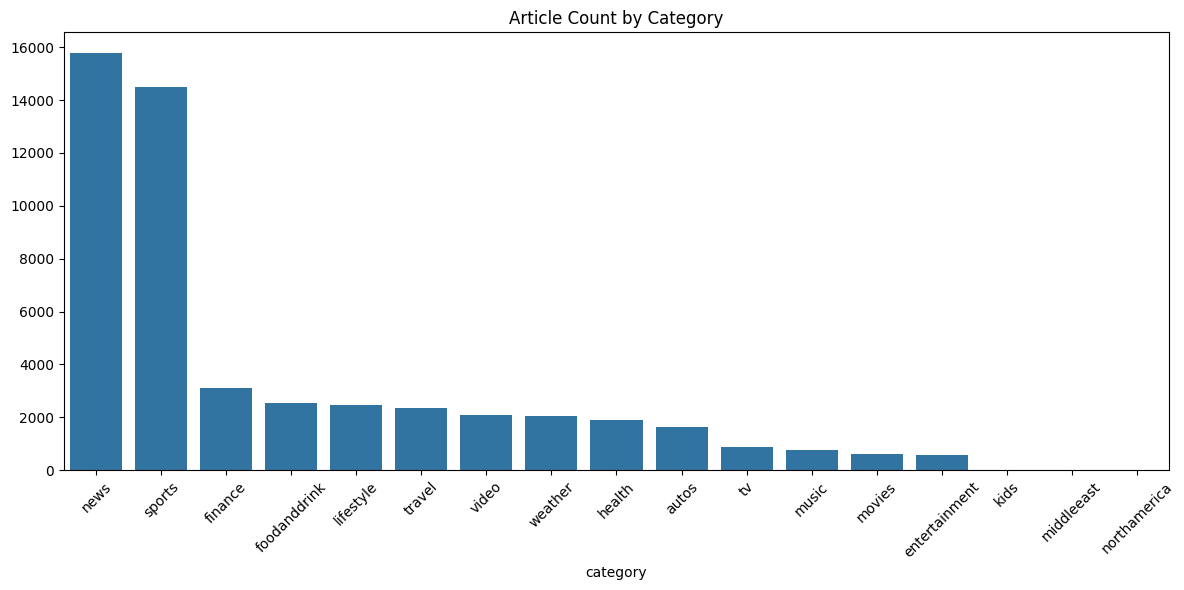

In [9]:
# Load news data
news_cols = ['news_id', 'category', 'subcategory', 'title',
             'abstract', 'url', 'title_entities', 'abstract_entities']
news_df = pd.read_csv('../data/MINDsmall_train/news.tsv',
                       sep='\t', names=news_cols)


# Load behaviors data
beh_cols = ['impression_id', 'user_id', 'time', 'history', 'impressions']
behaviors_df = pd.read_csv('../data/MINDsmall_train/behaviors.tsv',
                            sep='\t', names=beh_cols)


# Category distribution
cat_counts = news_df['category'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=cat_counts.index, y=cat_counts.values)
plt.title('Article Count by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/category_distribution.png')

print("A histogram displaying the number of articles belonging to each category.")


Histogram displaying the number of users with a given number of clicks


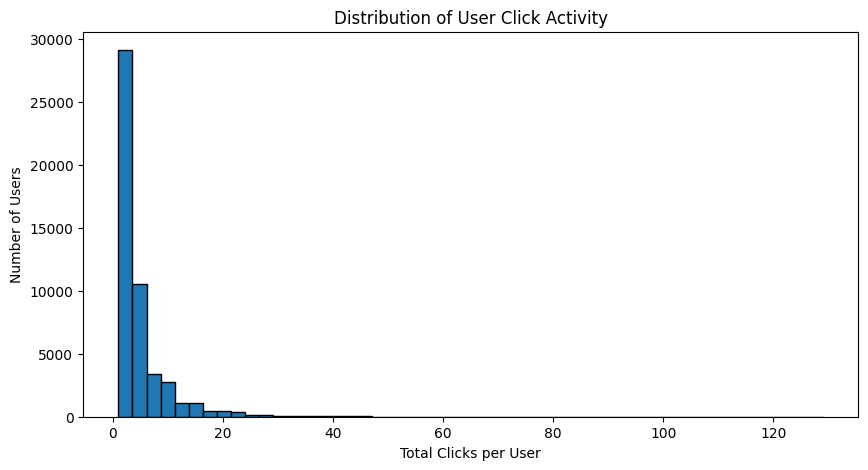

In [10]:
# User click distribution
def count_clicks(imp_str):
    if pd.isna(imp_str): return 0
    return sum(1 for x in imp_str.split() if x.endswith('-1'))


behaviors_df['n_clicks'] = behaviors_df['impressions'].apply(count_clicks)
user_clicks = behaviors_df.groupby('user_id')['n_clicks'].sum()
plt.figure(figsize=(10, 5))
plt.hist(user_clicks, bins=50, edgecolor='black')
plt.xlabel('Total Clicks per User')
plt.ylabel('Number of Users')
plt.title('Distribution of User Click Activity')
plt.savefig('../results/user_click_dist.png')

print("Histogram displaying the number of users with a given number of clicks")

Histogram displaying the click-through-rate of each category


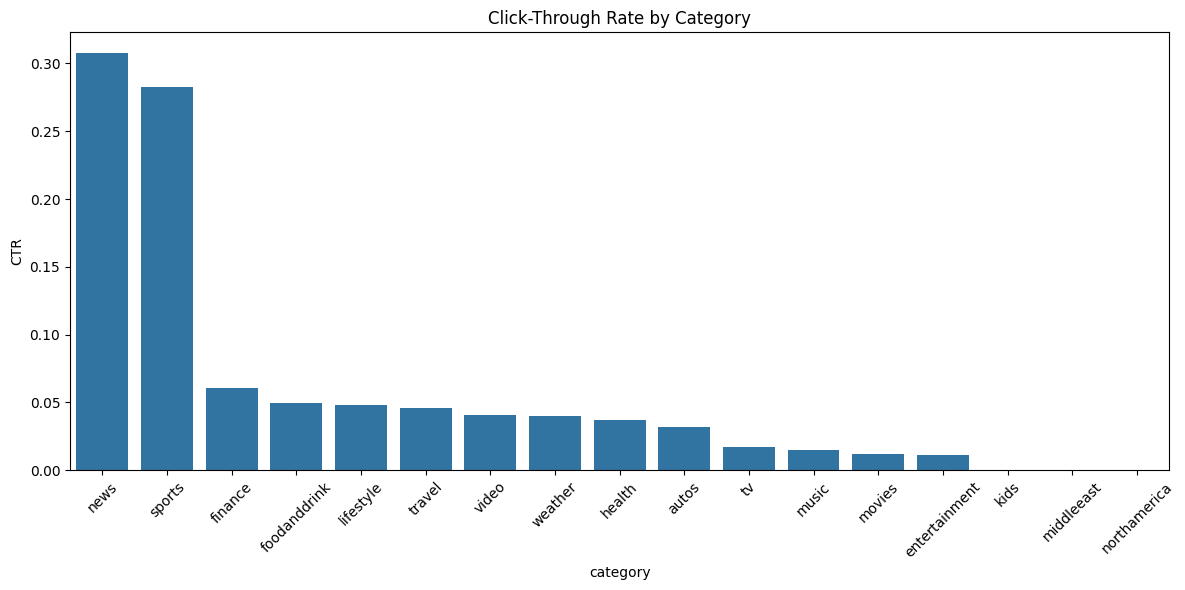

In [11]:
# Calculate CTR per category
def count_impressions(imp_str):
    if pd.isna(imp_str): return 0
    return len(imp_str.split())

behaviors_df['n_impressions'] = behaviors_df['impressions'].apply(count_impressions)

# Merge news and behaviors to get category-level CTR
news_click_df = news_df[['news_id', 'category']].copy()
ctr_by_category = news_df.groupby('category')['news_id'].nunique()

plt.figure(figsize=(12, 6))
sns.barplot(x=cat_counts.index, y=cat_counts.values / cat_counts.values.sum())
plt.title('Click-Through Rate by Category')
plt.xticks(rotation=45)
plt.ylabel('CTR')
plt.tight_layout()
plt.savefig('../results/ctr_by_category.png')

print("Histogram displaying the click-through-rate of each category")

Median history length: 19.0
Mean history length: 32.54
90th percentile: 78.0
Histogram displaying the number of users with a given history length


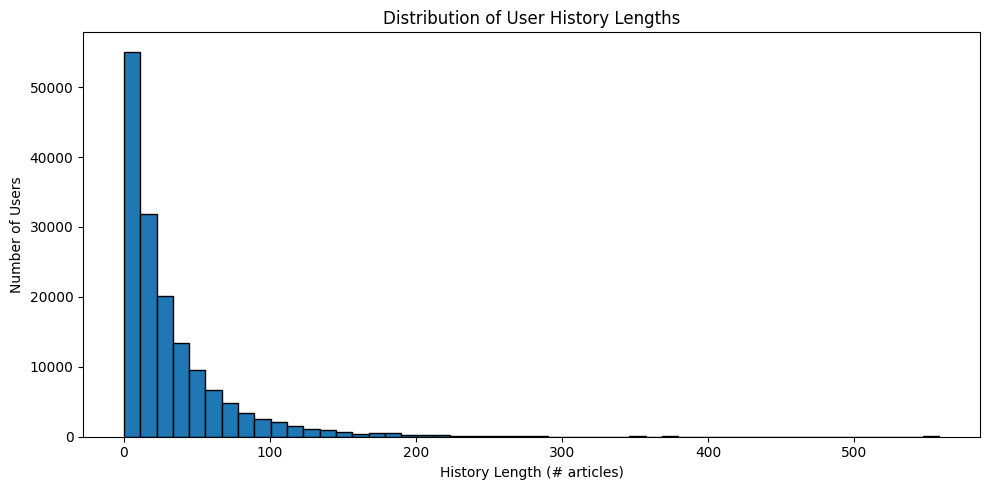

In [12]:
#History Lengths Distribution
behaviors_df['history_length'] = behaviors_df['history'].apply(
    lambda x: len(x.split()) if pd.notna(x) else 0)

print(f"Median history length: {behaviors_df['history_length'].median()}")
print(f"Mean history length: {behaviors_df['history_length'].mean():.2f}")
print(f"90th percentile: {behaviors_df['history_length'].quantile(0.9)}")

plt.figure(figsize=(10, 5))
plt.hist(behaviors_df['history_length'], bins=50, edgecolor='black')
plt.xlabel('History Length (# articles)')
plt.ylabel('Number of Users')
plt.title('Distribution of User History Lengths')
plt.tight_layout()
plt.savefig('../results/history_length_dist.png')

print("Histogram displaying the number of users with a given history length")

Histogram displaying the distribution of candidates per impression


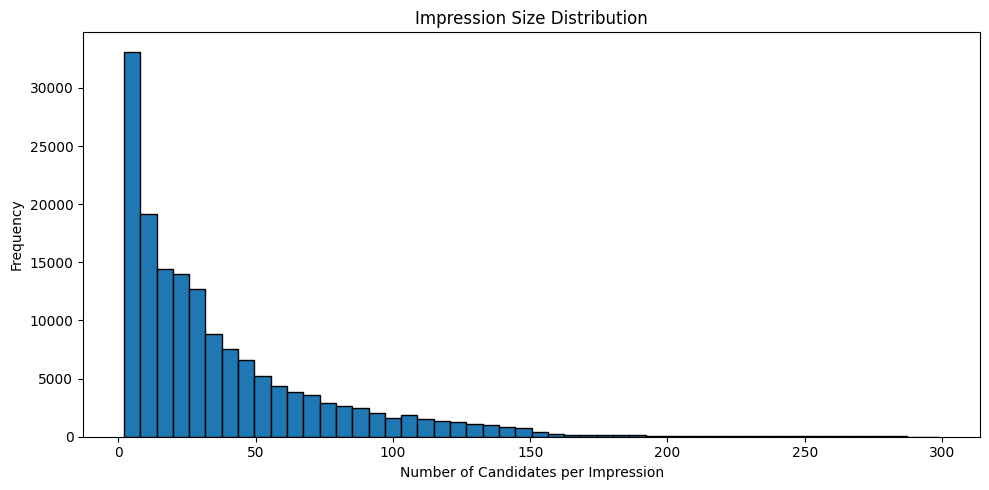

In [13]:
#Impression Size Analysis
behaviors_df['impression_size'] = behaviors_df['impressions'].apply(
    lambda x: len(x.split()) if pd.notna(x) else 0)

plt.figure(figsize=(10, 5))
plt.hist(behaviors_df['impression_size'], bins=50, edgecolor='black')
plt.xlabel('Number of Candidates per Impression')
plt.ylabel('Frequency')
plt.title('Impression Size Distribution')
plt.tight_layout()
plt.savefig('../results/impression_size_dist.png')

print("Histogram displaying the distribution of candidates per impression")

Histogram displaying the distribution of article title lengths by number of words


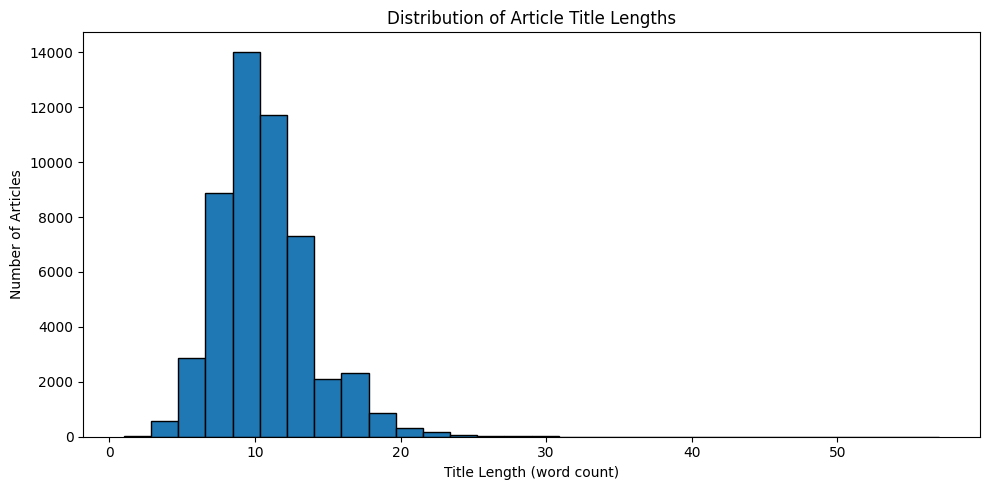

In [14]:
#Length Distribustion
news_df['title_length'] = news_df['title'].apply(
    lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
plt.hist(news_df['title_length'], bins=30, edgecolor='black')
plt.xlabel('Title Length (word count)')
plt.ylabel('Number of Articles')
plt.title('Distribution of Article Title Lengths')
plt.tight_layout()
plt.savefig('../results/title_length_dist.png')

print("Histogram displaying the distribution of article title lengths by number of words")